In [17]:
# =============================================================
# IMPORTS
# =============================================================
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [18]:
# =============================================================
# DATASET
# =============================================================

# MNIST: 60000 train / 10000 test изображений 28x28

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [19]:
# нормализация в [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# преобразование изображений в вектор
# автоэнкодеры работают с вектором признаков
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# размер латентного пространства
latent_dim = 2

In [20]:
# =============================================================
# VAE
# =============================================================

# слой с reparameterization trick

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs

        # ε ~ N(0,1)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        # z = μ + σ * ε
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [21]:
# -----------------------------
# Encoder VAE
# -----------------------------

encoder_inputs = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)

# encoder предсказывает параметры распределения
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# sampling из распределения
z = Sampling()([z_mean, z_log_var])

encoder_vae = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z]
)

In [22]:
# -----------------------------
# Decoder VAE
# -----------------------------

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)

# вероятность пикселя
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder_vae = keras.Model(latent_inputs, decoder_outputs)

In [23]:
# =============================================================
# VAE MODEL
# =============================================================

# BinaryCrossentropy без автоматической редукции
bce = keras.losses.BinaryCrossentropy(reduction="none")


class VAE(keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            # encoder
            z_mean, z_log_var, z = self.encoder(data)

            # decoder
            reconstruction = self.decoder(z)

            # reconstruction loss
            rec_loss = bce(data, reconstruction)

            # суммируем по пикселям
            rec_loss = tf.reduce_mean(tf.reduce_sum(rec_loss, axis=-1))

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            loss = rec_loss + kl_loss

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": loss,
            "reconstruction_loss": rec_loss,
            "kl_loss": kl_loss
        }

In [24]:
vae = VAE(encoder_vae, decoder_vae)

vae.compile(
    optimizer=keras.optimizers.Adam()
)

In [25]:
vae.fit(
    x_train,
    epochs=15,
    batch_size=128
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - kl_loss: 1.8228 - loss: 23.9251 - reconstruction_loss: 22.1023
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.1071 - loss: 23.2424 - reconstruction_loss: 21.1354
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 2.2407 - loss: 22.4631 - reconstruction_loss: 20.2224
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.3718 - loss: 23.1218 - reconstruction_loss: 20.7501
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.3715 - loss: 23.9691 - reconstruction_loss: 21.5977
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 2.5733 - loss: 22.7966 - reconstruction_loss: 20.2233
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.8619 - loss: 21.5477 - reconstruction_loss: 18.6857
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.6863 - loss: 22.3483 - reconstruction_loss: 19.6619
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss:

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


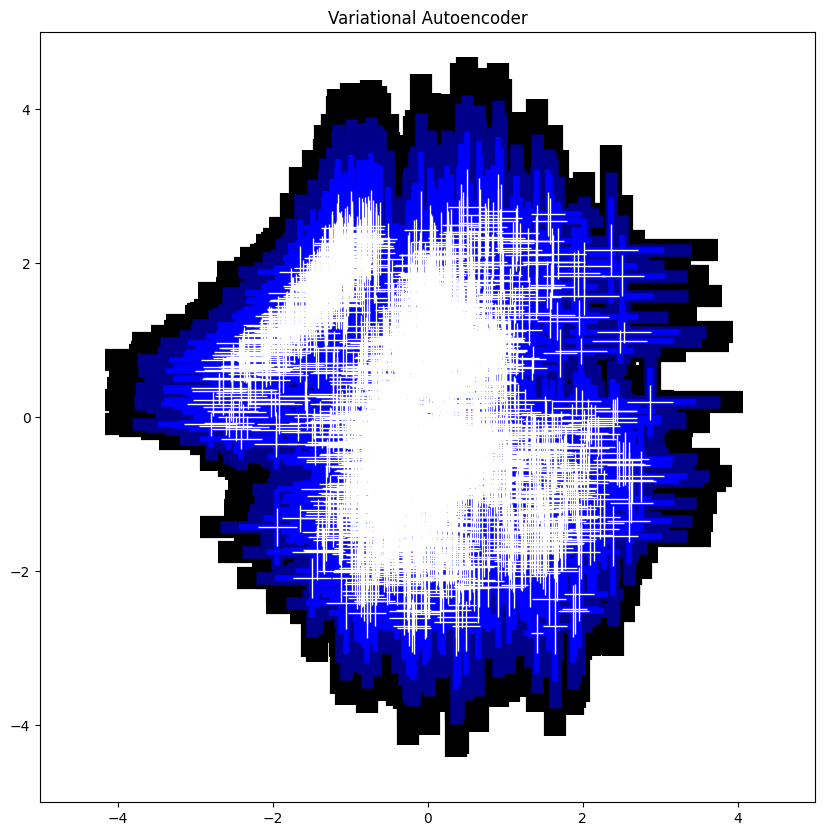

In [163]:
# =============================================================
# LATENT SPACE
# =============================================================
# VAE (используем mean)
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

k = 3000
z_mean, z_log_var, z = encoder_vae.predict(x_test[:k])

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test[:k], cmap="tab10", s=5)
ax.set_title("Variational Autoencoder")

for coef in [4,3,2,1]:
    segments = np.concat([((
                (mean[0] - coef*np.exp(0.5 * log[0]), mean[1]), (mean[0] + coef*np.exp(0.5 * log[0]), mean[1])),
            ((mean[0], mean[1] - coef*np.exp(0.5 * log[1])), (mean[0], mean[1] + coef*np.exp(0.5 * log[1]))))
        for mean, log in zip(z_mean, z_log_var)
    ])
    lc = LineCollection(segments, linewidths=coef*coef, edgecolors=["", "white", "blue", "darkblue", "black"][coef])
    ax.add_collection(lc)


ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
plt.show()

In [ ]:
# =============================================================
# GENERATION GRID VAE
# =============================================================

grid_size = 20

grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)

figure_vae = np.zeros((28 * grid_size, 28 * grid_size))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])

        # генерация из latent space
        x_decoded = decoder_vae.predict(z_sample, verbose=0)

        digit = x_decoded.reshape(28, 28)

        figure_vae[
        i * 28:(i + 1) * 28,
        j * 28:(j + 1) * 28
        ] = digit

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(figure_vae, cmap="gray")
plt.title("VAE latent space generation")
plt.show()